# Nuclearity Prediction from simple RDF-based descriptiors

This notebook aims at predicting the number of heavy atoms in the structure using several descriptors of a radial distribution function calculated as RDF(r) = G(r)*r + 4πρ₀*r².

**Dataset**: Calculated RDFs of ThxOy clusters (10000 unique clusters)

**Classes**: 9 total (nuclearities 1-9)

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz
import sys
from pathlib import Path

# Add parent directory to path for config import
sys.path.insert(0, '..')
from config import get_path, setup_workdir

Let's look at the distribution of clusters that we have.

Working directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/calculated_pdfs


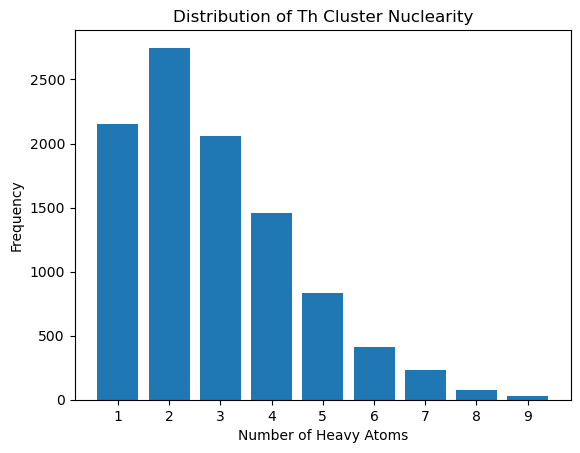

In [2]:
# Set working directory and paths using config
setup_workdir('th_calculated_pdfs')
labels_path = get_path('labels') / 'th_labels.txt'

def read_txt_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    return [int(line.strip()) for line in lines]

def count_occurrences(numbers):
    count_dict = {str(i): 0 for i in range(1, 10)}
    for number in numbers:
        count_dict[str(number)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    numbers = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.bar(numbers, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.title('Distribution of Th Cluster Nuclearity')
    plt.show()

numbers = read_txt_file(labels_path)
count_dict = count_occurrences(numbers)
plot_bar_chart(count_dict)

Let's start with preparing the data. We need to calculate the G(r)*r first from the G(r) files

PDF files directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/calculated_pdfs
RDF output directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/calculated_rdfs
Found 10000 PDF files to process
Processed 0 files...
Processed 1000 files...
Processed 2000 files...
Processed 3000 files...
Processed 4000 files...
Processed 5000 files...
Processed 6000 files...
Processed 7000 files...
Processed 8000 files...
Processed 9000 files...
Completed RDF calculation for 10000 files
  RDF files saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/calculated_rdfs


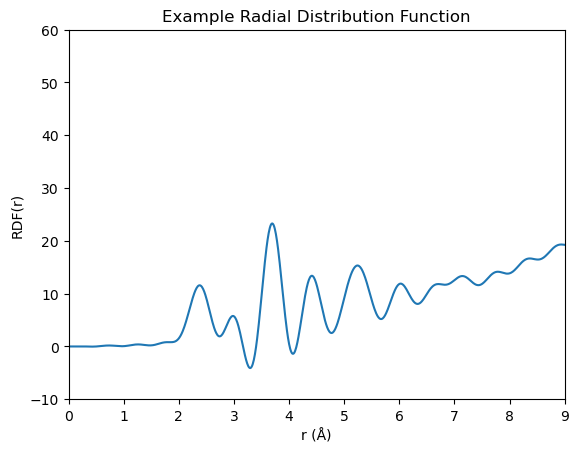

In [3]:
# Setup directories
pdf_dir = get_path('th_calculated_pdfs')
rdfs_dir = get_path('th_clusters') / 'calculated_rdfs'
rdfs_dir.mkdir(parents=True, exist_ok=True)

print(f"PDF files directory: {pdf_dir}")
print(f"RDF output directory: {rdfs_dir}")

files_calc = list(pdf_dir.glob('*.dat'))
print(f"Found {len(files_calc)} PDF files to process")

for i, f in enumerate(files_calc):  # Process ALL files
    data = pd.read_csv(f, skiprows=1, delim_whitespace=True, index_col=False)
    data.columns = ['r', 'g']
    df = pd.DataFrame(data)
    
    # Calculate RDF(r) = G(r)*r + 4πρ0 * r^2
    # Using density ρ0 = 4/175.33
    df['rdf'] = df.g * df.r + 4 * np.pi * 4 / 175.33 * df.r * df.r
    
    # Save RDF to the dedicated directory
    output_file = rdfs_dir / f.name.replace('.dat', '_radial.txt')
    df.to_csv(output_file, index_label=False, sep=' ', header=None, index=False)
    
    if i % 1000 == 0:
        print(f"Processed {i} files...")

print(f"Completed RDF calculation for {i+1} files")
print(f"  RDF files saved to: {rdfs_dir}")

# Plot example RDF
if len(files_calc) > 0:
    fig, ax = plt.subplots()
    ax.plot(df.r, df.rdf)
    ax.set_xlim(0, 9)
    ax.set_ylim(-10, 60)
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('RDF(r)')
    ax.set_title('Example Radial Distribution Function')
    plt.show()

In [20]:
# Enhanced feature extraction from RDF files
files_radial = list(rdfs_dir.glob('*_radial.txt'))

# Save features to dedicated rdf_features folder (consistent with PDF notebook)
rdf_features_dir = get_path('th_clusters') / 'rdf_features'
rdf_features_dir.mkdir(parents=True, exist_ok=True)
features_path = rdf_features_dir / 'rdf_features.txt'

print(f"Found {len(files_radial)} RDF files for feature extraction")
print(f"Feature output directory: {rdf_features_dir}")

def extract_rdf_features(df):
    """Extract comprehensive RDF features for classification"""
    features = {}
    
    # Define peak regions
    peak1_mask = (df['r'] >= 2.0) & (df['r'] <= 3.0)
    peak2_mask = (df['r'] >= 3.5) & (df['r'] <= 4.2) 
    peak3_mask = (df['r'] >= 6.0) & (df['r'] <= 7.0)
    
    peak1 = df.loc[peak1_mask]
    peak2 = df.loc[peak2_mask]
    peak3 = df.loc[peak3_mask]
    
    # Peak areas (original features)
    area1 = trapz(peak1.rdf, peak1.r) if len(peak1) > 0 else 0
    area2 = trapz(peak2.rdf, peak2.r) if len(peak2) > 0 else 0
    area3 = trapz(peak3.rdf, peak3.r) if len(peak3) > 0 else 0
    
    features['area1'] = area1
    features['area2'] = area2  
    features['area3'] = area3
    
    # Peak intensity ratios (original + additional)
    features['ratio_21'] = area2/area1 if area1 > 0 else 0
    features['ratio_23'] = area2/area3 if area3 > 0 else 0
    features['ratio_31'] = area3/area1 if area1 > 0 else 0
    
    # Peak positions (r-values at maximum intensity)
    features['peak1_pos'] = peak1.loc[peak1.rdf.idxmax(), 'r'] if len(peak1) > 0 and peak1.rdf.max() > 0 else 2.5
    features['peak2_pos'] = peak2.loc[peak2.rdf.idxmax(), 'r'] if len(peak2) > 0 and peak2.rdf.max() > 0 else 3.85
    features['peak3_pos'] = peak3.loc[peak3.rdf.idxmax(), 'r'] if len(peak3) > 0 and peak3.rdf.max() > 0 else 6.5
    
    # Peak heights (maximum intensities)
    features['peak1_height'] = peak1.rdf.max() if len(peak1) > 0 else 0
    features['peak2_height'] = peak2.rdf.max() if len(peak2) > 0 else 0
    features['peak3_height'] = peak3.rdf.max() if len(peak3) > 0 else 0
    
    # Peak height ratios
    features['height_21'] = features['peak2_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    features['height_31'] = features['peak3_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    
    # Coordination shell integrals (broader regions)
    shell1_mask = (df['r'] >= 1.5) & (df['r'] <= 3.5)
    shell2_mask = (df['r'] >= 3.0) & (df['r'] <= 5.0)
    shell3_mask = (df['r'] >= 5.5) & (df['r'] <= 7.5)
    
    features['shell1_coord'] = trapz(df.loc[shell1_mask, 'rdf'], df.loc[shell1_mask, 'r']) if shell1_mask.any() else 0
    features['shell2_coord'] = trapz(df.loc[shell2_mask, 'rdf'], df.loc[shell2_mask, 'r']) if shell2_mask.any() else 0
    features['shell3_coord'] = trapz(df.loc[shell3_mask, 'rdf'], df.loc[shell3_mask, 'r']) if shell3_mask.any() else 0
    
    # RDF moments and shape descriptors
    r_vals = df['r'].values
    rdf_vals = df['rdf'].values
    
    # First moment (weighted average r-position)
    if np.sum(rdf_vals) > 0:
        features['moment1'] = np.sum(r_vals * rdf_vals) / np.sum(rdf_vals)
        features['moment2'] = np.sum((r_vals - features['moment1'])**2 * rdf_vals) / np.sum(rdf_vals)  # Variance
    else:
        features['moment1'] = 0
        features['moment2'] = 0
    
    # Total RDF integral (0-10 Å)
    total_mask = (df['r'] >= 0) & (df['r'] <= 10)
    features['total_integral'] = trapz(df.loc[total_mask, 'rdf'], df.loc[total_mask, 'r']) if total_mask.any() else 0
    
    return features

# Extract features from all RDF files
all_features = []
with open(features_path, 'w') as f:
    # Write header
    feature_names = ['nuclearity', 'area1', 'area2', 'area3', 'ratio_21', 'ratio_23', 'ratio_31',
                     'peak1_pos', 'peak2_pos', 'peak3_pos', 'peak1_height', 'peak2_height', 'peak3_height',
                     'height_21', 'height_31', 'shell1_coord', 'shell2_coord', 'shell3_coord', 
                     'moment1', 'moment2', 'total_integral']
    f.write(' '.join(feature_names) + '\n')
    
    for i, file_path in enumerate(files_radial):  # Process ALL RDF files
        try:
            # Load RDF data
            data = pd.read_csv(file_path, delim_whitespace=True, index_col=False)
            data.columns = ['r', 'g', 'rdf']
            
            # Extract features
            features = extract_rdf_features(data)
            
            # Get nuclearity from filename
            nuclearity = int(file_path.name[0])
            
            # Write to file
            feature_row = [nuclearity] + [features[name] for name in feature_names[1:]]
            f.write(' '.join(map(str, feature_row)) + '\n')
            all_features.append(feature_row)
            
        except Exception as e:
            print(f"Error processing {file_path.name}: {e}")
            continue
            
        if i % 1000 == 0:
            print(f"Extracted features from {i} files...")

print(f"\nFeature extraction complete")
print(f"  Features saved to: {features_path}")
print(f"  Total features per sample: {len(feature_names)-1}")    

Found 10000 RDF files for feature extraction
Feature output directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/rdf_features
Extracted features from 0 files...
Extracted features from 1000 files...
Extracted features from 2000 files...
Extracted features from 3000 files...
Extracted features from 4000 files...
Extracted features from 5000 files...
Extracted features from 6000 files...
Extracted features from 7000 files...
Extracted features from 8000 files...
Extracted features from 9000 files...

Feature extraction complete
  Features saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/rdf_features/rdf_features.txt
  Total features per sample: 20


Loaded 10000 samples with 20 features
Nuclearity distribution:
1    2153
2    2748
3    2055
4    1461
5     832
6     415
7     230
8      79
9      27
Name: nuclearity, dtype: int64


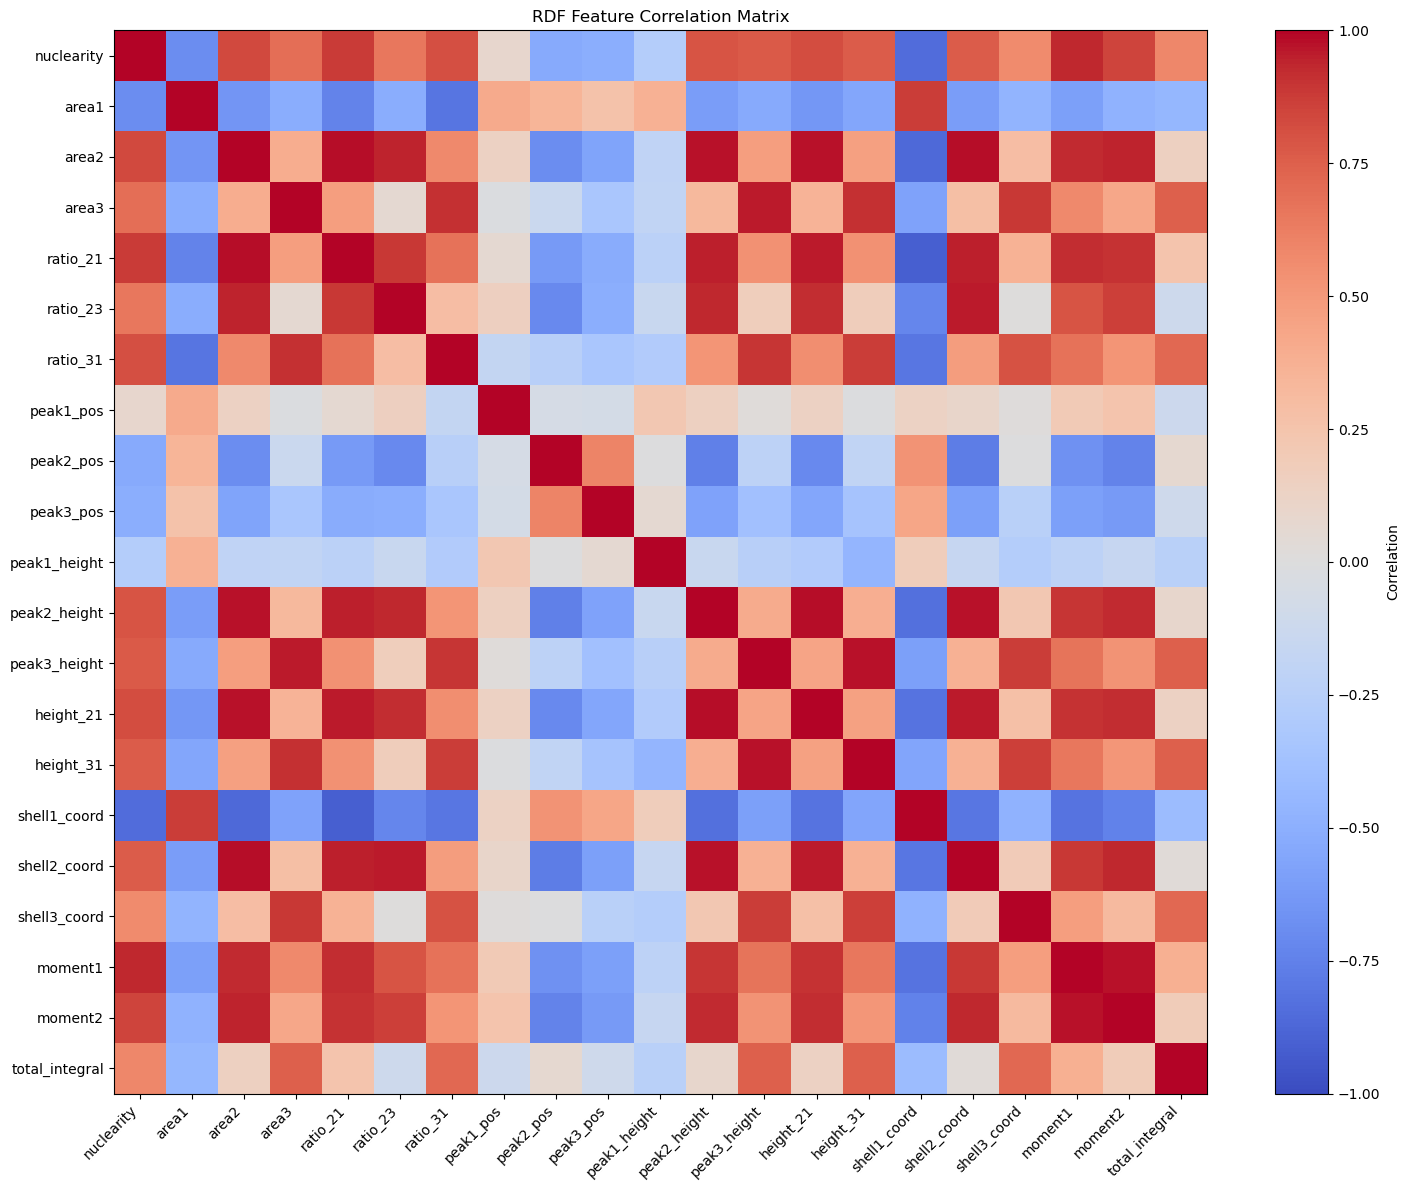

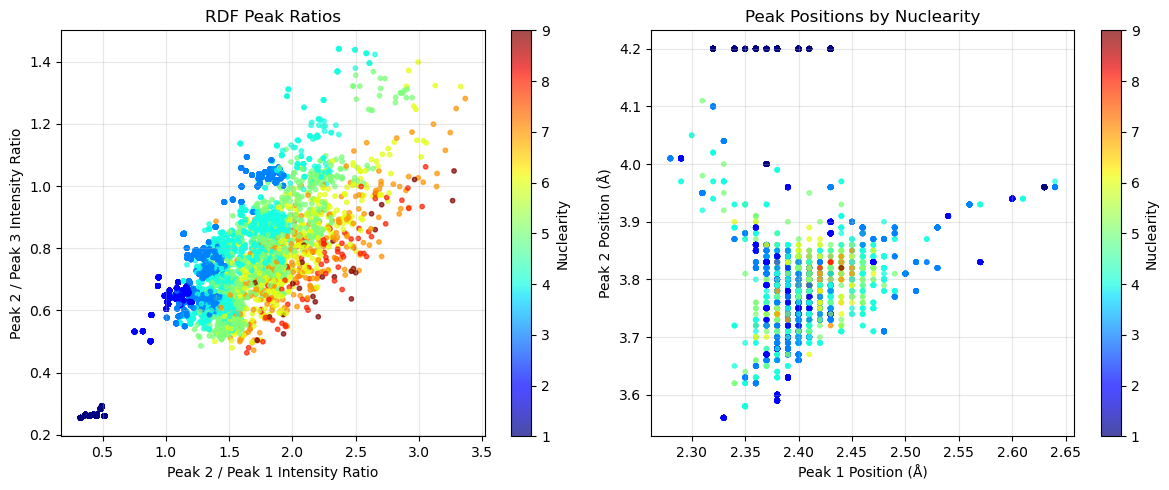


Feature statistics:
       nuclearity      area1      area2      area3   ratio_21   ratio_23  \
count   10000.000  10000.000  10000.000  10000.000  10000.000  10000.000   
mean        2.879      6.148      7.143     11.406      1.203      0.625   
std         1.624      0.639      2.728      1.347      0.538      0.229   
min         1.000      4.494      2.697      9.408      0.326      0.255   
25%         2.000      5.678      6.038     10.508      0.885      0.540   
50%         3.000      6.033      7.144     10.890      1.173      0.646   
75%         4.000      6.450      8.523     12.165      1.522      0.743   
max         9.000      8.260     16.662     18.665      3.365      1.441   

        ratio_31  peak1_pos  peak2_pos  peak3_pos  ...  peak2_height  \
count  10000.000  10000.000  10000.000  10000.000  ...     10000.000   
mean       1.887      2.402      3.867      6.751  ...        19.903   
std        0.376      0.051      0.184      0.231  ...         9.340   
min   

In [ ]:
# Load and visualize RDF features
features_data = pd.read_csv(features_path, delim_whitespace=True, header=0, index_col=False)

print(f"Loaded {len(features_data)} samples with {features_data.shape[1]-1} features")
print(f"Nuclearity distribution:")
print(features_data['nuclearity'].value_counts().sort_index())
feature_names = list(features_data.columns)

# Visualize feature correlations
plt.figure(figsize=(15, 12))
correlation_matrix = features_data.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('RDF Feature Correlation Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(features_data['ratio_21'], features_data['ratio_23'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 2 / Peak 1 Intensity Ratio')
plt.ylabel('Peak 2 / Peak 3 Intensity Ratio')
plt.title('RDF Peak Ratios')
plt.colorbar(scatter1, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(features_data['peak1_pos'], features_data['peak2_pos'], 
                      c=features_data['nuclearity'], cmap='jet', s=10, alpha=0.7)
plt.xlabel('Peak 1 Position (Å)')
plt.ylabel('Peak 2 Position (Å)')
plt.title('Peak Positions by Nuclearity')
plt.colorbar(scatter2, label='Nuclearity')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display feature statistics
print("\nFeature statistics:")
print(features_data.describe().round(3))

Let's try the Gradient Boosting Machine regression model

Feature matrix shape: (10000, 20)
Target distribution: [   0 2153 2748 2055 1461  832  415  230   79   27]
Training Gradient Boosting Classifier...

Gradient Boosting Classification Results:
Accuracy: 0.956
F1-score (weighted): 0.952
F1-score (macro): 0.688

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       431
           2       1.00      1.00      1.00       550
           3       1.00      1.00      1.00       411
           4       0.96      0.99      0.97       292
           5       0.84      0.91      0.88       166
           6       0.73      0.61      0.67        83
           7       0.53      0.61      0.57        46
           8       0.50      0.06      0.11        16
           9       0.00      0.00      0.00         5

    accuracy                           0.96      2000
   macro avg       0.73      0.69      0.69      2000
weighted avg       0.95      0.96      0.95      2000


Cro

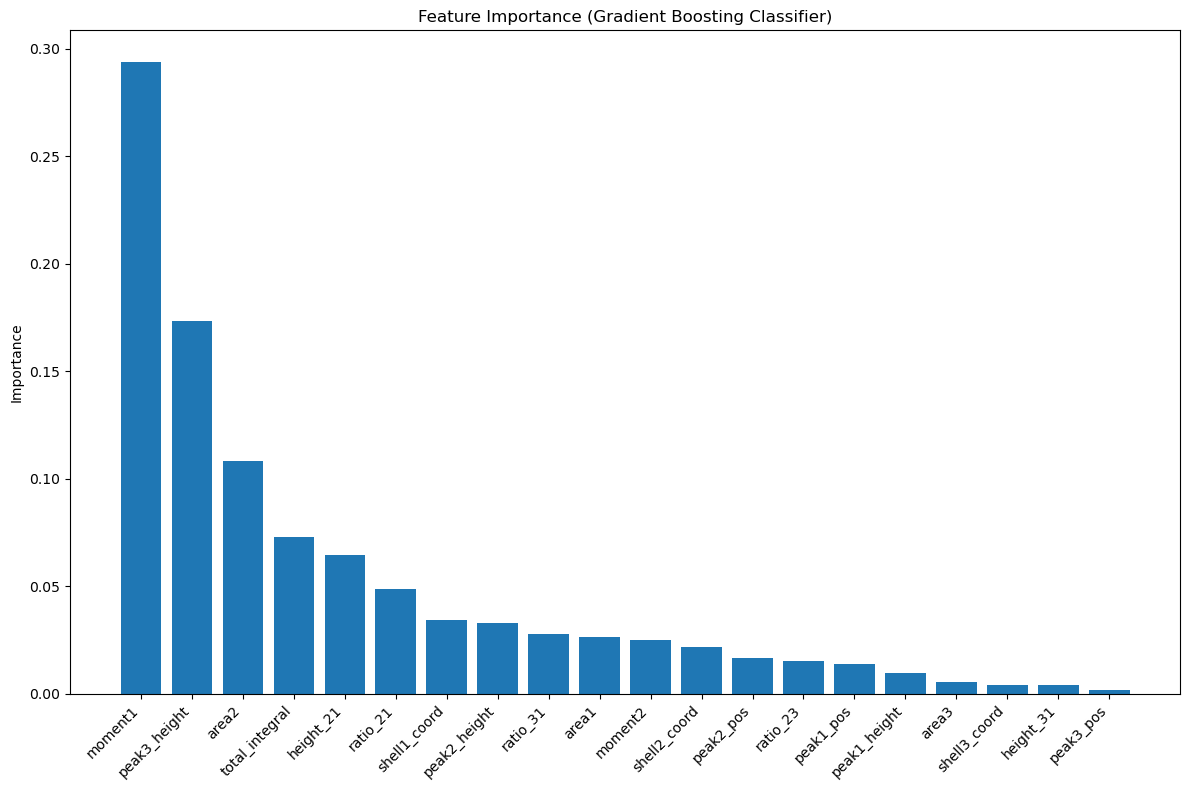


Top 5 most important features:
1. moment1: 0.294
2. peak3_height: 0.173
3. area2: 0.108
4. total_integral: 0.073
5. height_21: 0.065


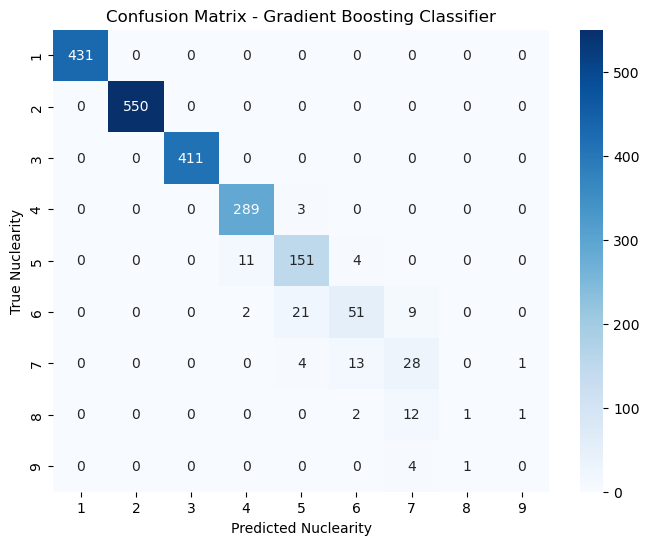

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=6,
    random_state=42
)

print("Training Gradient Boosting Classifier...")
gb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test_scaled)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\nGradient Boosting Classification Results:")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score (weighted): {f1_weighted:.3f}")
print(f"F1-score (macro): {f1_macro:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Cross-validation performance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_classifier, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
print(f"\nCross-validation F1-scores: {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Gradient Boosting Classifier)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important features:")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance[idx]:.3f}")

# Confusion matrix
plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
plt.xlabel('Predicted Nuclearity')
plt.ylabel('True Nuclearity')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.show()

Let's try random forest

Training Random Forest Classifier with hyperparameter tuning...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV score: 0.947

Random Forest Classification Results:
Accuracy: 0.956
F1-score (weighted): 0.952
F1-score (macro): 0.715

Detailed Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       431
           2       1.00      1.00      1.00       550
           3       1.00      1.00      1.00       411
           4       0.96      0.99      0.97       292
           5       0.81      0.93      0.87       166
           6       0.68      0.60      0.64        83
           7       0.56      0.41      0.47        46
           8       0.67      0.38      0.48        16
           9       0.00      0.00      0.00         5

    accuracy                           0.96

/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

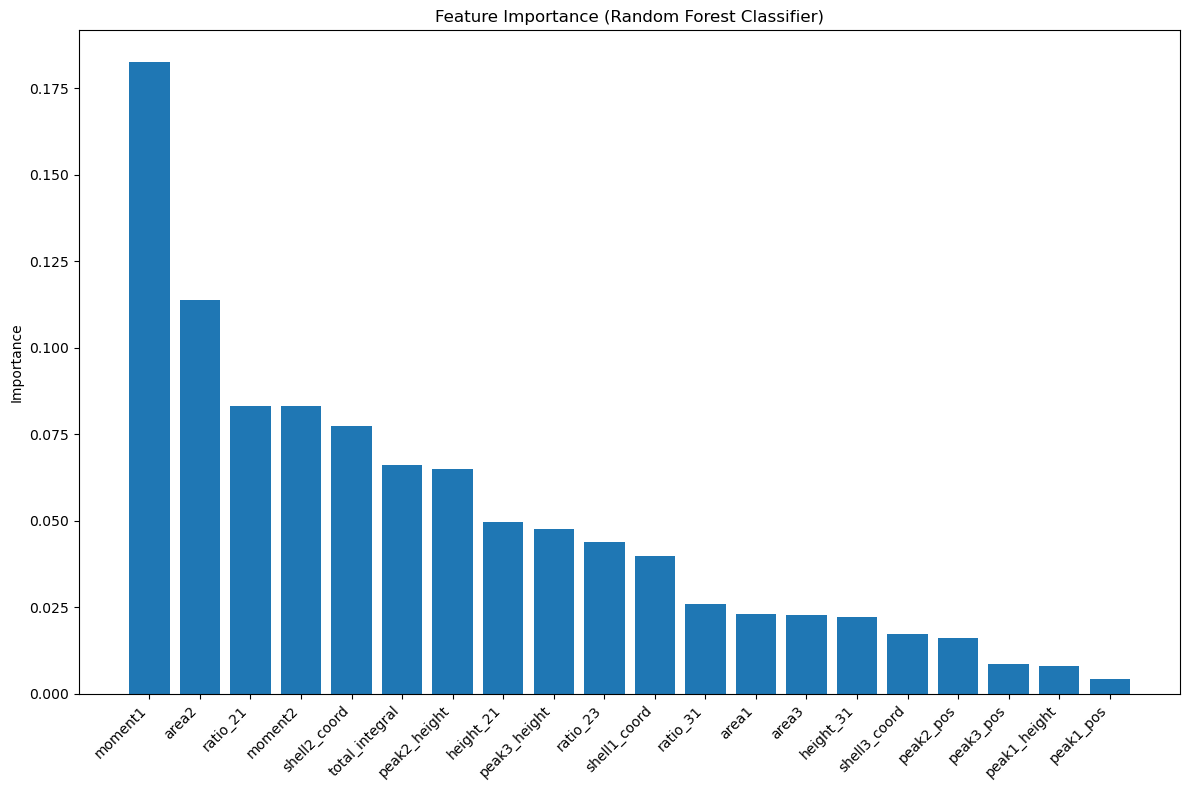


Top 5 most important features (Random Forest):
1. moment1: 0.183
2. area2: 0.114
3. ratio_21: 0.083
4. moment2: 0.083
5. shell2_coord: 0.077


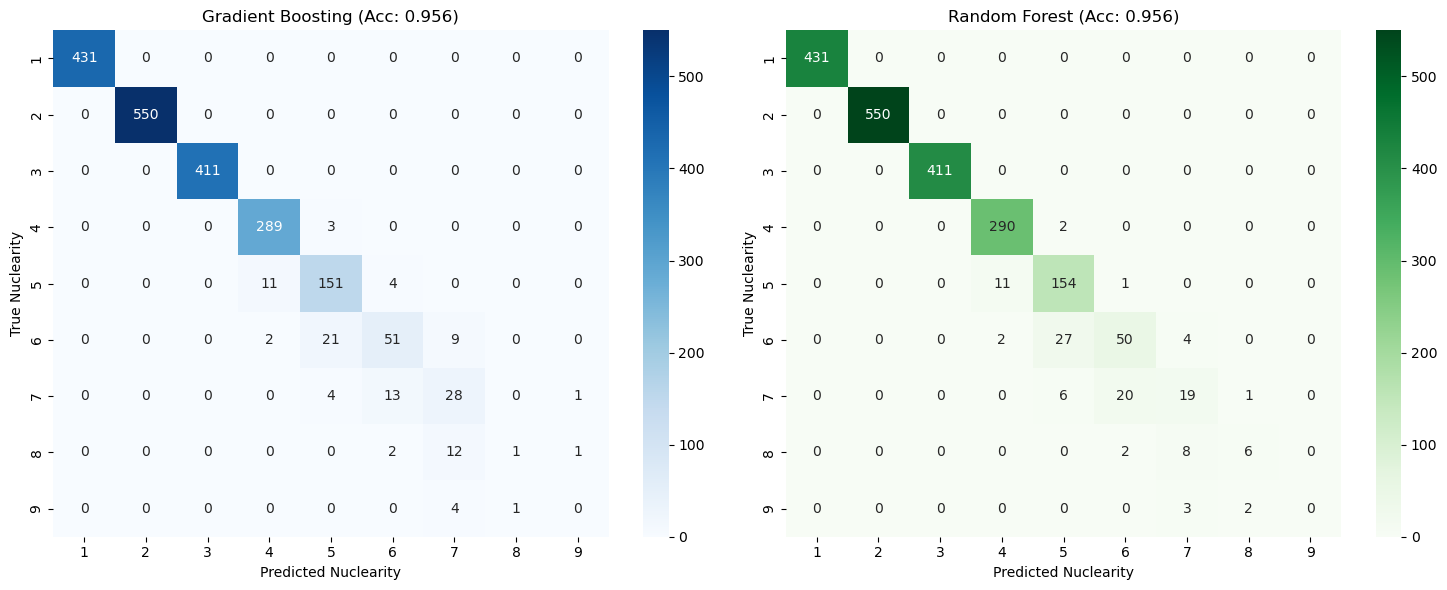


Per-class accuracy comparison:
Class      GB Precision    RF Precision    GB Recall    RF Recall   
----------------------------------------------------------------------
1          1.000           1.000           1.000        1.000       
2          1.000           1.000           1.000        1.000       
3          1.000           1.000           1.000        1.000       
4          0.957           0.957           0.990        0.993       
5          0.844           0.815           0.910        0.928       
6          0.729           0.685           0.614        0.602       
7          0.528           0.559           0.609        0.413       
8          0.500           0.667           0.062        0.375       
9          0.000           0.000           0.000        0.000       


/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest Classifier with hyperparameter tuning
print("Training Random Forest Classifier with hyperparameter tuning...")

# Define parameter grid for optimization
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Create Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(
    rf_classifier, 
    param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Get best model
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Make predictions with best model
y_pred_rf = best_rf.predict(X_test_scaled)

# Calculate classification metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')

print(f"\nRandom Forest Classification Results:")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"F1-score (weighted): {f1_weighted_rf:.3f}")
print(f"F1-score (macro): {f1_macro_rf:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance analysis
feature_importance_rf = best_rf.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.bar(range(len(feature_importance_rf)), feature_importance_rf[indices])
plt.xticks(range(len(feature_importance_rf)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest Classifier)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important features (Random Forest):")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance_rf[idx]:.3f}")

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gradient Boosting confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[0].set_xlabel('Predicted Nuclearity')
axes[0].set_ylabel('True Nuclearity')
axes[0].set_title(f'Gradient Boosting (Acc: {accuracy:.3f})')

# Random Forest confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1].set_xlabel('Predicted Nuclearity')
axes[1].set_ylabel('True Nuclearity')
axes[1].set_title(f'Random Forest (Acc: {accuracy_rf:.3f})')

plt.tight_layout()
plt.show()

# Calculate per-class accuracy
unique_classes = sorted(np.unique(y))
print(f"\nPer-class accuracy comparison:")
print(f"{'Class':<10} {'GB Precision':<15} {'RF Precision':<15} {'GB Recall':<12} {'RF Recall':<12}")
print("-" * 70)

from sklearn.metrics import precision_score, recall_score

for cls in unique_classes:
    gb_prec = precision_score(y_test == cls, y_pred == cls)
    rf_prec = precision_score(y_test == cls, y_pred_rf == cls)
    gb_rec = recall_score(y_test == cls, y_pred == cls)
    rf_rec = recall_score(y_test == cls, y_pred_rf == cls)
    print(f"{cls:<10} {gb_prec:<15.3f} {rf_prec:<15.3f} {gb_rec:<12.3f} {rf_rec:<12.3f}")

Let's try Bayesian approaches for classification

Enhanced feature matrix shape: (10000, 20)
Using 20 RDF features for Bayesian classification
Training Gaussian Naive Bayes Classifier...

Gaussian Naive Bayes Results:
Accuracy: 0.847
F1-score (weighted): 0.846
F1-score (macro): 0.571

Training Bayesian Logistic Regression...

Bayesian Logistic Regression Results:
Accuracy: 0.794
F1-score (weighted): 0.765
F1-score (macro): 0.425

Cross-validation F1-scores:
Naive Bayes:    0.845 (+/- 0.010)
Bayesian LogReg: 0.759 (+/- 0.015)


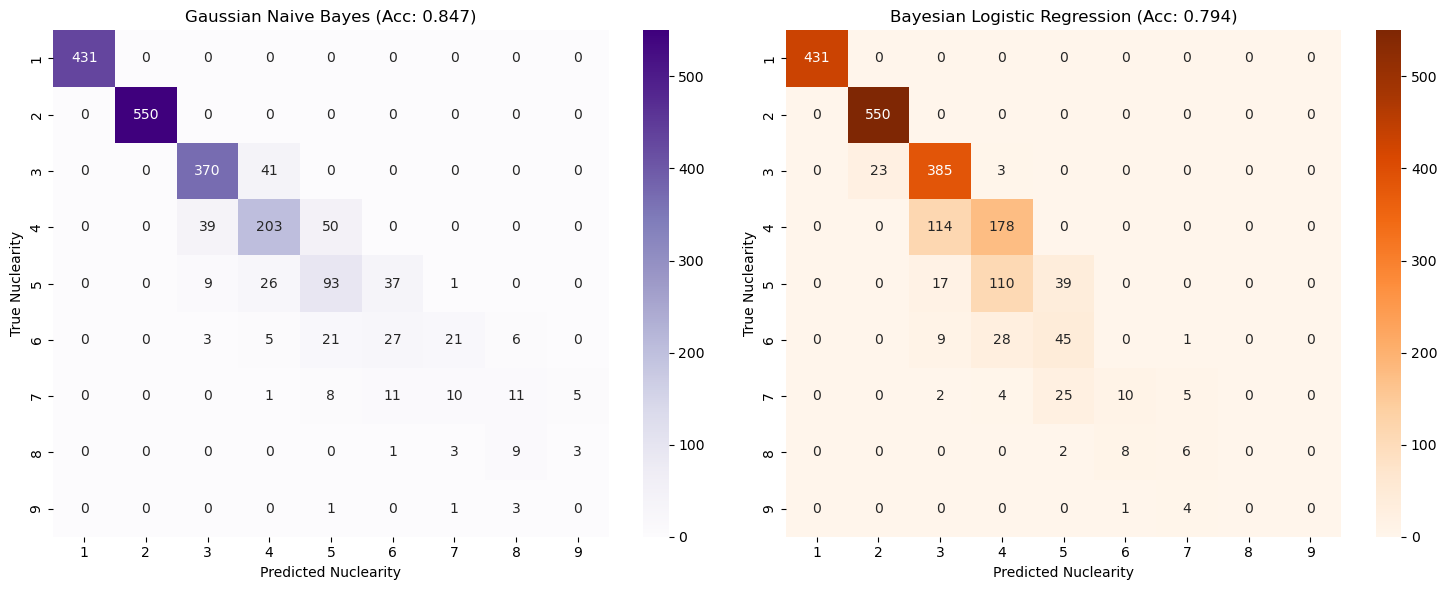

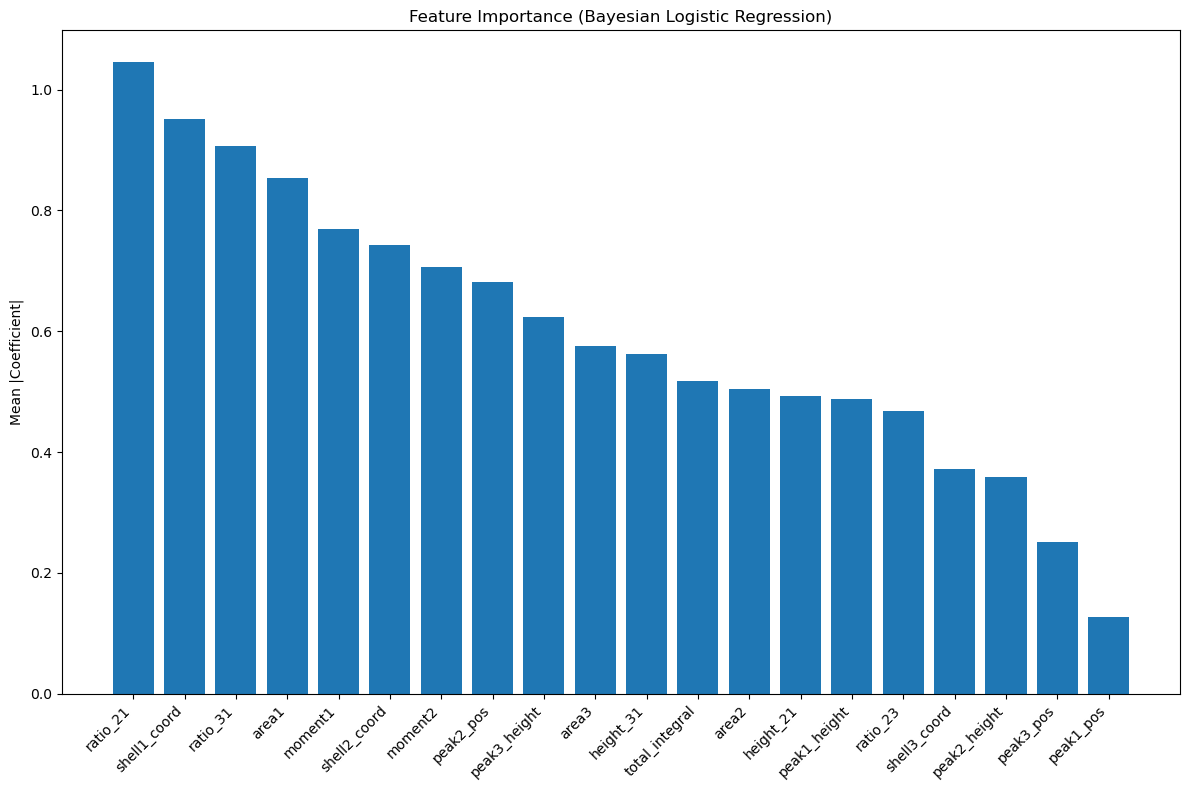


Top 5 most important features (Bayesian LogReg):
1. ratio_21: 1.046
2. shell1_coord: 0.952
3. ratio_31: 0.907
4. area1: 0.853
5. moment1: 0.769

Prediction Confidence Analysis:
Average prediction confidence:
  Naive Bayes: 0.939 (+/- 0.121)
  Bayesian LogReg: 0.645 (+/- 0.217)


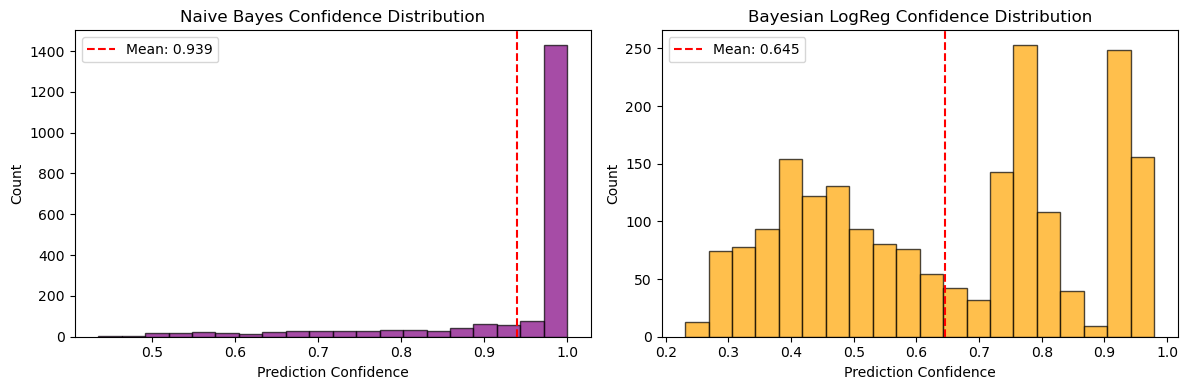

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Use the enhanced feature set for Bayesian classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Enhanced feature matrix shape: {X.shape}")
print(f"Using {len(feature_names)-1} RDF features for Bayesian classification")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# 1. Gaussian Naive Bayes (Pure Bayesian Classifier)
# ============================================================================
print("Training Gaussian Naive Bayes Classifier...")
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred_nb = nb_classifier.predict(X_test_scaled)
y_prob_nb = nb_classifier.predict_proba(X_test_scaled)

# Calculate metrics
accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_weighted_nb = f1_score(y_test, y_pred_nb, average='weighted')
f1_macro_nb = f1_score(y_test, y_pred_nb, average='macro')

print(f"\nGaussian Naive Bayes Results:")
print(f"Accuracy: {accuracy_nb:.3f}")
print(f"F1-score (weighted): {f1_weighted_nb:.3f}")
print(f"F1-score (macro): {f1_macro_nb:.3f}")

# ============================================================================
# 2. Bayesian Logistic Regression (with L2 regularization)
# ============================================================================
print("\nTraining Bayesian Logistic Regression...")
bayesian_lr = LogisticRegression(
    penalty='l2',
    C=0.1,  # Strong regularization (Bayesian-like)
    solver='lbfgs',
    max_iter=1000,
    multi_class='ovr',
    random_state=42
)

bayesian_lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = bayesian_lr.predict(X_test_scaled)
y_prob_lr = bayesian_lr.predict_proba(X_test_scaled)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_weighted_lr = f1_score(y_test, y_pred_lr, average='weighted')
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f"\nBayesian Logistic Regression Results:")
print(f"Accuracy: {accuracy_lr:.3f}")
print(f"F1-score (weighted): {f1_weighted_lr:.3f}")
print(f"F1-score (macro): {f1_macro_lr:.3f}")

# ============================================================================
# Cross-validation comparison
# ============================================================================
cv_scores_nb = cross_val_score(nb_classifier, X_train_scaled, y_train, cv=5, scoring='f1_weighted')
cv_scores_lr = cross_val_score(bayesian_lr, X_train_scaled, y_train, cv=5, scoring='f1_weighted')

print(f"\nCross-validation F1-scores:")
print(f"Naive Bayes:    {cv_scores_nb.mean():.3f} (+/- {cv_scores_nb.std() * 2:.3f})")
print(f"Bayesian LogReg: {cv_scores_lr.mean():.3f} (+/- {cv_scores_lr.std() * 2:.3f})")

# ============================================================================
# Visualization: Confusion matrices comparison
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Naive Bayes confusion matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[0].set_xlabel('Predicted Nuclearity')
axes[0].set_ylabel('True Nuclearity')
axes[0].set_title(f'Gaussian Naive Bayes (Acc: {accuracy_nb:.3f})')

# Bayesian Logistic Regression confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1].set_xlabel('Predicted Nuclearity')
axes[1].set_ylabel('True Nuclearity')
axes[1].set_title(f'Bayesian Logistic Regression (Acc: {accuracy_lr:.3f})')

plt.tight_layout()
plt.show()

# ============================================================================
# Feature importance from Bayesian Logistic Regression
# ============================================================================
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

# For multiclass, take mean absolute coefficients across classes
feature_importance_lr = np.mean(np.abs(bayesian_lr.coef_), axis=0)

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_lr)[::-1]
plt.bar(range(len(feature_importance_lr)), feature_importance_lr[indices])
plt.xticks(range(len(feature_importance_lr)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Bayesian Logistic Regression)')
plt.ylabel('Mean |Coefficient|')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most important features (Bayesian LogReg):")
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {feature_names_clean[idx]}: {feature_importance_lr[idx]:.3f}")

# ============================================================================
# Prediction confidence analysis
# ============================================================================
print(f"\nPrediction Confidence Analysis:")

# Calculate average confidence (max probability) for each method
conf_nb = np.max(y_prob_nb, axis=1)
conf_lr = np.max(y_prob_lr, axis=1)

print(f"Average prediction confidence:")
print(f"  Naive Bayes: {conf_nb.mean():.3f} (+/- {conf_nb.std():.3f})")
print(f"  Bayesian LogReg: {conf_lr.mean():.3f} (+/- {conf_lr.std():.3f})")

# Plot confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(conf_nb, bins=20, alpha=0.7, color='purple', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Naive Bayes Confidence Distribution')
axes[0].axvline(conf_nb.mean(), color='red', linestyle='--', label=f'Mean: {conf_nb.mean():.3f}')
axes[0].legend()

axes[1].hist(conf_lr, bins=20, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Bayesian LogReg Confidence Distribution')
axes[1].axvline(conf_lr.mean(), color='red', linestyle='--', label=f'Mean: {conf_lr.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

IMPROVING BAYESIAN APPROACHES

1. Feature Selection for Naive Bayes
Selected features: ['area1', 'area2', 'area3', 'ratio_21', 'ratio_31', 'peak3_height', 'height_31', 'shell1_coord', 'moment1', 'total_integral']
Improved Naive Bayes (feature selection): 0.879 accuracy, 0.879 F1

2. Hyperparameter Tuning for Bayesian LogReg
Best LogReg params: {'C': 100, 'max_iter': 1000, 'solver': 'liblinear'}
Improved Bayesian LogReg: 0.848 accuracy, 0.839 F1

3. Feature Engineering - Polynomial Features (limited)
Polynomial features: 15 features from top 5
LogReg + Polynomial Features: 0.939 accuracy, 0.935 F1

4. Ensemble of Bayesian Methods
Bayesian Ensemble: 0.860 accuracy, 0.859 F1


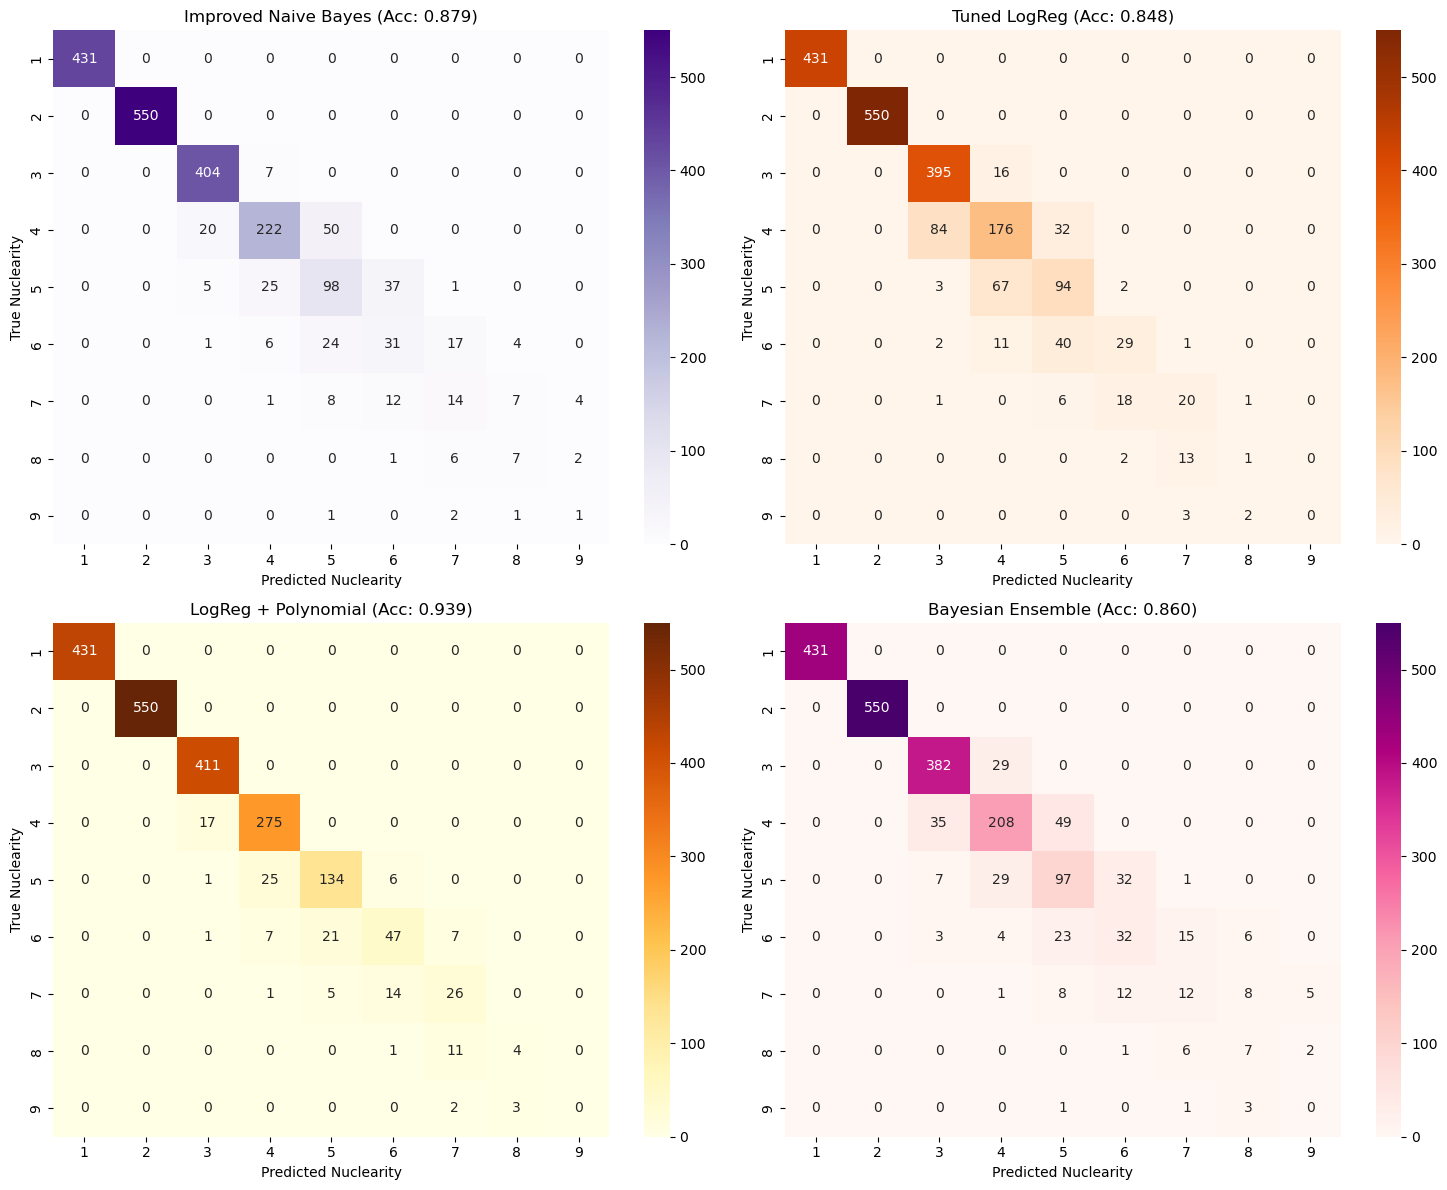


BAYESIAN METHODS - IMPROVEMENT SUMMARY
Method                              Before       After        Improvement 
----------------------------------------------------------------------
Naive Bayes (feature selection)     0.847        0.879        +0.032
Logistic Regression (tuned)         0.794        0.848        +0.054
LogReg + Polynomial Features        0.794        0.939        +0.145
Bayesian Ensemble                   N/A          0.860        NEW


In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("IMPROVING BAYESIAN APPROACHES")
print("="*50)

# ============================================================================
# Strategy 1: Feature Selection for Naive Bayes
# ============================================================================
print("\n1. Feature Selection for Naive Bayes")

# Use mutual information to select most informative features
selector = SelectKBest(score_func=mutual_info_classif, k=10)  # Select top 10 features
X_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = np.array(feature_names_clean)[selector.get_support()]
print(f"Selected features: {list(selected_features)}")

# Train Naive Bayes on selected features
nb_improved = GaussianNB()
nb_improved.fit(X_selected, y_train)
y_pred_nb_improved = nb_improved.predict(X_test_selected)

accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
f1_nb_improved = f1_score(y_test, y_pred_nb_improved, average='weighted')

print(f"Improved Naive Bayes (feature selection): {accuracy_nb_improved:.3f} accuracy, {f1_nb_improved:.3f} F1")

# ============================================================================
# Strategy 2: Relaxed Regularization for Logistic Regression  
# ============================================================================
print("\n2. Hyperparameter Tuning for Bayesian LogReg")

# Grid search for optimal regularization
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Less to more regularization
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, multi_class='ovr'),
    param_grid_lr,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"Best LogReg params: {lr_grid.best_params_}")

y_pred_lr_improved = lr_grid.predict(X_test_scaled)
accuracy_lr_improved = accuracy_score(y_test, y_pred_lr_improved)
f1_lr_improved = f1_score(y_test, y_pred_lr_improved, average='weighted')

print(f"Improved Bayesian LogReg: {accuracy_lr_improved:.3f} accuracy, {f1_lr_improved:.3f} F1")

# ============================================================================
# Strategy 3: Feature Engineering for Bayesian Methods
# ============================================================================
print("\n3. Feature Engineering - Polynomial Features (limited)")

from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features for top 5 most important features (from RF)
# This captures feature interactions without creating too many features
feature_importance_rf = best_rf.feature_importances_
top_5_indices = np.argsort(feature_importance_rf)[-5:]
X_train_top5 = X_train_scaled[:, top_5_indices]
X_test_top5 = X_test_scaled[:, top_5_indices]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top5)
X_test_poly = poly.transform(X_test_top5)

print(f"Polynomial features: {X_train_poly.shape[1]} features from top 5")

# Train LogReg on polynomial features
lr_poly = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

accuracy_lr_poly = accuracy_score(y_test, y_pred_lr_poly)
f1_lr_poly = f1_score(y_test, y_pred_lr_poly, average='weighted')

print(f"LogReg + Polynomial Features: {accuracy_lr_poly:.3f} accuracy, {f1_lr_poly:.3f} F1")

# ============================================================================
# Strategy 4: Ensemble Bayesian Approaches
# ============================================================================
print("\n4. Ensemble of Bayesian Methods")

# Create ensemble of improved Bayesian methods
bayesian_ensemble = VotingClassifier([
    ('lr_tuned', lr_grid.best_estimator_),
    ('nb', GaussianNB())  # Simple NB on full features
], voting='soft')

bayesian_ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = bayesian_ensemble.predict(X_test_scaled)

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, average='weighted')

print(f"Bayesian Ensemble: {accuracy_ensemble:.3f} accuracy, {f1_ensemble:.3f} F1")

# ============================================================================
# Confusion matrices for improved methods
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Improved Naive Bayes
conf_matrix_nb_imp = confusion_matrix(y_test, y_pred_nb_improved)
sns.heatmap(conf_matrix_nb_imp, annot=True, fmt='d', cmap='Purples', ax=axes[0, 0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[0, 0].set_xlabel('Predicted Nuclearity')
axes[0, 0].set_ylabel('True Nuclearity')
axes[0, 0].set_title(f'Improved Naive Bayes (Acc: {accuracy_nb_improved:.3f})')

# Improved Logistic Regression
conf_matrix_lr_imp = confusion_matrix(y_test, y_pred_lr_improved)
sns.heatmap(conf_matrix_lr_imp, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[0, 1].set_xlabel('Predicted Nuclearity')
axes[0, 1].set_ylabel('True Nuclearity')
axes[0, 1].set_title(f'Tuned LogReg (Acc: {accuracy_lr_improved:.3f})')

# LogReg + Polynomial
conf_matrix_lr_poly = confusion_matrix(y_test, y_pred_lr_poly)
sns.heatmap(conf_matrix_lr_poly, annot=True, fmt='d', cmap='YlOrBr', ax=axes[1, 0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1, 0].set_xlabel('Predicted Nuclearity')
axes[1, 0].set_ylabel('True Nuclearity')
axes[1, 0].set_title(f'LogReg + Polynomial (Acc: {accuracy_lr_poly:.3f})')

# Bayesian Ensemble
conf_matrix_ens = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(conf_matrix_ens, annot=True, fmt='d', cmap='RdPu', ax=axes[1, 1],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1, 1].set_xlabel('Predicted Nuclearity')
axes[1, 1].set_ylabel('True Nuclearity')
axes[1, 1].set_title(f'Bayesian Ensemble (Acc: {accuracy_ensemble:.3f})')

plt.tight_layout()
plt.show()

print(f"\n" + "="*70)
print("BAYESIAN METHODS - IMPROVEMENT SUMMARY")
print("="*70)
print(f"{'Method':<35} {'Before':<12} {'After':<12} {'Improvement':<12}")
print("-"*70)
print(f"{'Naive Bayes (feature selection)':<35} {accuracy_nb:.3f}        {accuracy_nb_improved:.3f}        {accuracy_nb_improved-accuracy_nb:+.3f}")
print(f"{'Logistic Regression (tuned)':<35} {accuracy_lr:.3f}        {accuracy_lr_improved:.3f}        {accuracy_lr_improved-accuracy_lr:+.3f}")
print(f"{'LogReg + Polynomial Features':<35} {accuracy_lr:.3f}        {accuracy_lr_poly:.3f}        {accuracy_lr_poly-accuracy_lr:+.3f}")
print(f"{'Bayesian Ensemble':<35} N/A          {accuracy_ensemble:.3f}        NEW")
print("="*70)

Let's try an enhanced neural network classifier with the full feature set

Neural network input: 20 features
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Building neural network for PDF-based nuclearity classification...
Model architecture:
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 128)               2688      
                                                                 
 batch_normalization_18 (Bat  (None, 128)              512       
 chNormalization)                                                
                                                                 
 dropout_24 (Dropout)        (None, 128)               0         
                                                                 
 dense_31 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_19 (Bat  (None, 64)               256       
 chNormalization)           

/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/dimitrygrebenyuk/miniforge3/envs/keras/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

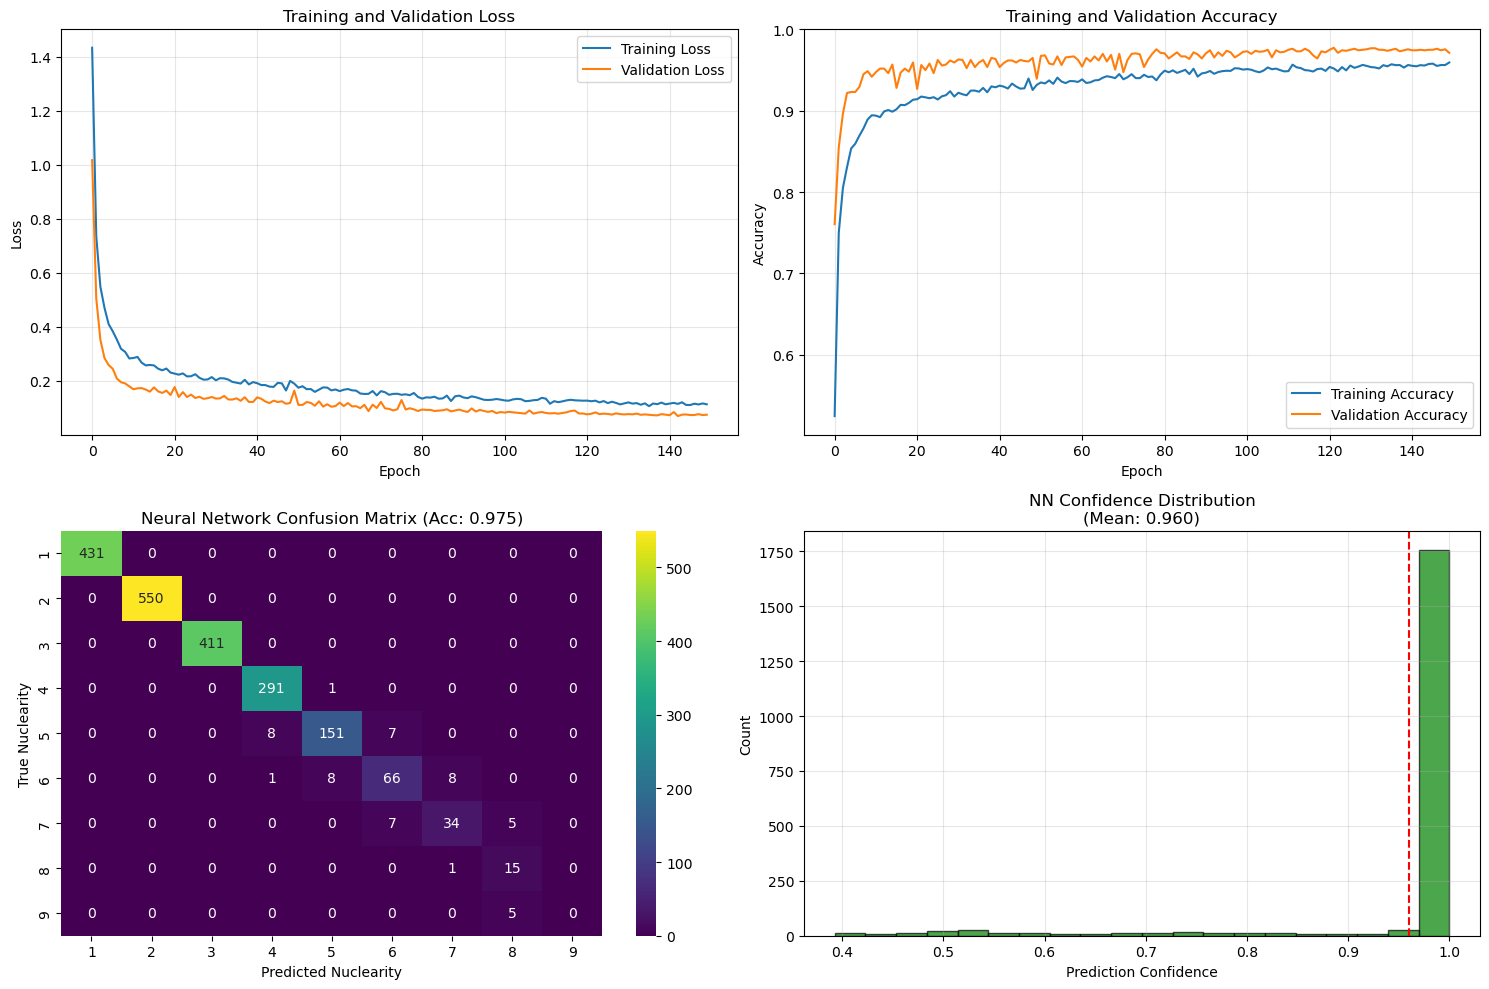

In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for neural network
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Neural network input: {X.shape[1]} features")
print(f"Classes: {sorted(np.unique(y))}")

# Convert to categorical for classification
num_classes = len(np.unique(y))
y_categorical = keras.utils.to_categorical(y - 1, num_classes)  # -1 because nuclearity starts at 1

# Split the data
X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y, y_categorical, test_size=0.2, random_state=42, stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build neural network
print("Building neural network for PDF-based nuclearity classification...")

model = keras.Sequential([
    # Input layer with dropout for regularization
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden layers with decreasing size
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    # Output layer for classification
    layers.Dense(num_classes, activation='softmax')
])

# Compile with appropriate loss for classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'categorical_crossentropy']
)

print(f"Model architecture:")
model.summary()

# Training with early stopping and learning rate reduction
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
]

print("\nTraining enhanced neural network...")
num_epochs = 150
history = model.fit(
    X_train_scaled, y_cat_train,
    batch_size=64,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Evaluation and predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1  # +1 to convert back to nuclearity

# Calculate classification metrics
accuracy_nn = accuracy_score(y_test, y_pred_classes)
f1_weighted_nn = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro_nn = f1_score(y_test, y_pred_classes, average='macro')

print(f"\nEnhanced Neural Network Classification Results:")
print(f"Accuracy: {accuracy_nn:.3f}")
print(f"F1-score (weighted): {f1_weighted_nn:.3f}")
print(f"F1-score (macro): {f1_macro_nn:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Visualization: Training history and confusion matrix
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training history - Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training history - Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='viridis', ax=axes[1, 0],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[1, 0].set_xlabel('Predicted Nuclearity')
axes[1, 0].set_ylabel('True Nuclearity')
axes[1, 0].set_title(f'Neural Network Confusion Matrix (Acc: {accuracy_nn:.3f})')

# Prediction confidence distribution
confidence_scores = np.max(y_pred_prob, axis=1)
axes[1, 1].hist(confidence_scores, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_xlabel('Prediction Confidence')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'NN Confidence Distribution\n(Mean: {confidence_scores.mean():.3f})')
axes[1, 1].axvline(confidence_scores.mean(), color='red', linestyle='--')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [33]:
# ============================================================================
# FINAL ALGORITHM COMPARISON - RDF FEATURES
# ============================================================================
print(f"\n" + "="*70)
print("FINAL ALGORITHM PERFORMANCE COMPARISON (RDF Features)")
print("="*70)
print(f"{'Algorithm':<35} {'Accuracy':<12} {'F1-Weighted':<12}")
print("-"*70)
print(f"{'Neural Network':<35} {accuracy_nn:.3f}        {f1_weighted_nn:.3f}")
print(f"{'Gradient Boosting':<35} {accuracy:.3f}        {f1_weighted:.3f}")
print(f"{'Random Forest':<35} {accuracy_rf:.3f}        {f1_weighted_rf:.3f}")
print(f"{'LogReg + Polynomial':<35} {accuracy_lr_poly:.3f}        {f1_lr_poly:.3f}")
print(f"{'Bayesian Ensemble':<35} {accuracy_ensemble:.3f}        {f1_ensemble:.3f}")
print(f"{'Naive Bayes (selected)':<35} {accuracy_nb_improved:.3f}        {f1_nb_improved:.3f}")
print(f"{'Tuned Logistic Regression':<35} {accuracy_lr_improved:.3f}        {f1_lr_improved:.3f}")
print("="*70)

# Identify best performing algorithms
algorithms = ['Gradient Boosting', 'Random Forest', 'Naive Bayes (improved)', 
              'Tuned LogReg', 'LogReg+Poly', 'Bayesian Ensemble', 'Neural Network']
accuracies = [accuracy, accuracy_rf, accuracy_nb_improved, 
              accuracy_lr_improved, accuracy_lr_poly, accuracy_ensemble, accuracy_nn]
f1_scores = [f1_weighted, f1_weighted_rf, f1_nb_improved, 
             f1_lr_improved, f1_lr_poly, f1_ensemble, f1_weighted_nn]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"\nBest Accuracy: {algorithms[best_acc_idx]} ({accuracies[best_acc_idx]:.3f})")
print(f"Best F1-Score: {algorithms[best_f1_idx]} ({f1_scores[best_f1_idx]:.3f})")

print("\n" + "="*70)
print("Analysis complete! Results saved to:", rdf_features_dir)


FINAL ALGORITHM PERFORMANCE COMPARISON (RDF Features)
Algorithm                           Accuracy     F1-Weighted 
----------------------------------------------------------------------
Neural Network                      0.967        0.963
Gradient Boosting                   0.956        0.952
Random Forest                       0.956        0.952
LogReg + Polynomial                 0.939        0.935
Bayesian Ensemble                   0.860        0.859
Naive Bayes (selected)              0.879        0.879
Tuned Logistic Regression           0.848        0.839

Best Accuracy: Neural Network (0.967)
Best F1-Score: Neural Network (0.963)

Analysis complete! Results saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/th_clusters/rdf_features
